In [ ]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 12)


,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [ ]:
# IT24102748 : SVM Implementation
# =====================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# 1. MODEL SELECTION AND JUSTIFICATION
print("\n1. MODEL SELECTION AND JUSTIFICATION")
print("""
Why SVM for Heart Disease Prediction:
- Effective in high-dimensional medical feature spaces
- Memory efficient using support vectors only
- Versatile with different kernel functions for complex patterns
- Robust against overfitting in medical data
- Handles complex non-linear decision boundaries
- Provides good generalization performance
- Suitable for medical pattern recognition
- Works well with standardized clinical data
""")


# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"Target distribution:\n{df['heart_disease'].value_counts()}")

# Prepare features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
feature_names = X.columns.tolist()

print(f"\nFeature names: {feature_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

# Feature scaling for SVM (CRITICAL for distance-based algorithms)
print("\nApplying feature scaling for SVM...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully")

# Handle class imbalance with SMOTE
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_train_smote)}")


1. MODEL SELECTION AND JUSTIFICATION

Why SVM for Heart Disease Prediction:
- Effective in high-dimensional medical feature spaces
- Memory efficient using support vectors only
- Versatile with different kernel functions for complex patterns
- Robust against overfitting in medical data
- Handles complex non-linear decision boundaries
- Provides good generalization performance
- Suitable for medical pattern recognition
- Works well with standardized clinical data

Dataset shape: (1025, 12)
Features: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia', 'heart_disease']
Target distribution:
heart_disease
1    526
0    499
Name: count, dtype: int64

Feature names: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia']
Training set: (717, 11)
Test set: (308, 11)
Class dis

In [ ]:
# 2. IMPLEMENTATION DETAILS
print("\n2. IMPLEMENTATION DETAILS")

# Base SVM
print("\nBase Model Implementation")
svm_base = SVC(random_state=42, probability=True)
svm_base.fit(X_train_scaled, y_train)
y_pred_base = svm_base.predict(X_test_scaled)


2. IMPLEMENTATION DETAILS

Base Model Implementation


In [ ]:
# 3. PARAMETER TUNING METHODS
print("\n3. PARAMETER TUNING WITH GRIDSEARCHCV")

# Define a more focused parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 1],
    'class_weight': ['balanced', None]
}


print(f"Parameter combinations to test: {len(param_grid['C']) * len(param_grid['kernel']) * len(param_grid['gamma']) * len(param_grid['class_weight'])}")
print(f"Total fits with 5-fold CV: {len(param_grid['C']) * len(param_grid['kernel']) * len(param_grid['gamma']) * len(param_grid['class_weight']) * 5}")

# GridSearchCV for hyperparameter tuning
svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Performing hyperparameter tuning...")
svm_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best cross-validation score: {svm_grid.best_score_:.4f}")

# Train best model
best_svm = svm_grid.best_estimator_


3. PARAMETER TUNING WITH GRIDSEARCHCV
Parameter combinations to test: 36
Total fits with 5-fold CV: 180
Performing hyperparameter tuning...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'C': 10, 'class_weight': None, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.9519


In [ ]:
# 4. MODEL VARIETIES
print("\n4. MODEL VARIETIES IMPLEMENTED")

# Variety 1: Base SVM
svm_v1 = SVC(random_state=42, probability=True)
svm_v1.fit(X_train_scaled, y_train)

# Variety 2: SVM with class weighting
svm_v2 = SVC(class_weight='balanced', random_state=42, probability=True)
svm_v2.fit(X_train_scaled, y_train)

# Variety 3: Tuned SVM
svm_v3 = best_svm

# Variety 4: SVM with SMOTE
svm_v4 = SVC(random_state=42, probability=True)
svm_v4.fit(X_train_smote, y_train_smote)

# Variety 5: Linear SVM (interpretable)
svm_v5 = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm_v5.fit(X_train_scaled, y_train)

# Variety 6: RBF SVM with high regularization
svm_v6 = SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42, probability=True)
svm_v6.fit(X_train_scaled, y_train)

# Variety 7: Polynomial SVM for complex patterns
svm_v7 = SVC(kernel='poly', degree=3, C=1.0, random_state=42, probability=True)
svm_v7.fit(X_train_scaled, y_train)

varieties = {
    'Base SVM': svm_v1,
    'Class-Weighted SVM': svm_v2,
    'Tuned SVM': svm_v3,
    'SVM with SMOTE': svm_v4,
    'Linear SVM': svm_v5,
    'RBF SVM (C=0.1)': svm_v6,
    'Polynomial SVM': svm_v7
}


4. MODEL VARIETIES IMPLEMENTED


In [ ]:
# 5. EVALUATION METRICS
print("\n5. COMPREHENSIVE EVALUATION")

def evaluate_svm_variety(model, X_test, y_test, variety_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{variety_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

    return metrics

# Evaluate all varieties
results = {}
for name, model in varieties.items():
    results[name] = evaluate_svm_variety(model, X_test_scaled, y_test, name)


5. COMPREHENSIVE EVALUATION

Base SVM:
  Accuracy: 0.9091
  Precision: 0.9276
  Recall: 0.8924
  F1-Score: 0.9097
  ROC-AUC: 0.9620

Class-Weighted SVM:
  Accuracy: 0.9091
  Precision: 0.9276
  Recall: 0.8924
  F1-Score: 0.9097
  ROC-AUC: 0.9619

Tuned SVM:
  Accuracy: 0.9643
  Precision: 0.9742
  Recall: 0.9557
  F1-Score: 0.9649
  ROC-AUC: 0.9878

SVM with SMOTE:
  Accuracy: 0.9091
  Precision: 0.9276
  Recall: 0.8924
  F1-Score: 0.9097
  ROC-AUC: 0.9615

Linear SVM:
  Accuracy: 0.8506
  Precision: 0.8256
  Recall: 0.8987
  F1-Score: 0.8606
  ROC-AUC: 0.9273

RBF SVM (C=0.1):
  Accuracy: 0.8474
  Precision: 0.8246
  Recall: 0.8924
  F1-Score: 0.8571
  ROC-AUC: 0.9390

Polynomial SVM:
  Accuracy: 0.9123
  Precision: 0.8922
  Recall: 0.9430
  F1-Score: 0.9169
  ROC-AUC: 0.9659


In [ ]:
# 6. CROSS-VALIDATION
print("\n6. CROSS-VALIDATION RESULTS")
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


6. CROSS-VALIDATION RESULTS
Cross-validation F1 scores: [0.93706294 0.96       0.95890411 0.95774648 0.97333333]
Mean CV F1: 0.9574 (+/- 0.0233)


In [ ]:
# 7. FEATURE IMPORTANCE ANALYSIS
print("\n7. FEATURE IMPORTANCE ANALYSIS")

# For linear SVM, we can get feature importance from coefficients
if hasattr(best_svm, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': abs(best_svm.coef_[0])
    }).sort_values('importance', ascending=False)

    print("\nFeature Importance (Linear Coefficients):")
    print(feature_importance)
else:
    # For non-linear kernels, use permutation importance as approximation
    from sklearn.inspection import permutation_importance

    print("\nCalculating permutation importance for non-linear SVM...")
    perm_importance = permutation_importance(
        best_svm, X_test_scaled, y_test,
        n_repeats=10, random_state=42, scoring='f1'
    )

    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': perm_importance.importances_mean
    }).sort_values('importance', ascending=False)

    print("Feature Importance (Permutation):")
    print(feature_importance)


7. FEATURE IMPORTANCE ANALYSIS

Calculating permutation importance for non-linear SVM...
Feature Importance (Permutation):
              feature  importance
9   num_major_vessels    0.118007
4     chest_pain_type    0.088196
1                 sex    0.080541
6       st_depression    0.077167
10        thalassemia    0.063283
0                 age    0.063114
3      max_heart_rate    0.058134
5         resting_ecg    0.054782
7            st_slope    0.044695
8     exercise_angina    0.039120
2          resting_bp    0.022941


In [ ]:
# 8. MODEL COMPARISON AND INSIGHTS
print("\n8. MODEL COMPARISON AND INSIGHTS")

comparison_df = pd.DataFrame(results).T
print("\nSVM Varieties Comparison:")
print(comparison_df.round(4))

best_variety_svm = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing variety: {best_variety_svm}")
print(f"Best F1-Score: {comparison_df.loc[best_variety_svm, 'F1-Score']:.4f}")



8. MODEL COMPARISON AND INSIGHTS

SVM Varieties Comparison:
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
Base SVM              0.9091     0.9276  0.8924    0.9097   0.9620
Class-Weighted SVM    0.9091     0.9276  0.8924    0.9097   0.9619
Tuned SVM             0.9643     0.9742  0.9557    0.9649   0.9878
SVM with SMOTE        0.9091     0.9276  0.8924    0.9097   0.9615
Linear SVM            0.8506     0.8256  0.8987    0.8606   0.9273
RBF SVM (C=0.1)       0.8474     0.8246  0.8924    0.8571   0.9390
Polynomial SVM        0.9123     0.8922  0.9430    0.9169   0.9659

Best performing variety: Tuned SVM
Best F1-Score: 0.9649



9. GENERATING VISUALIZATIONS


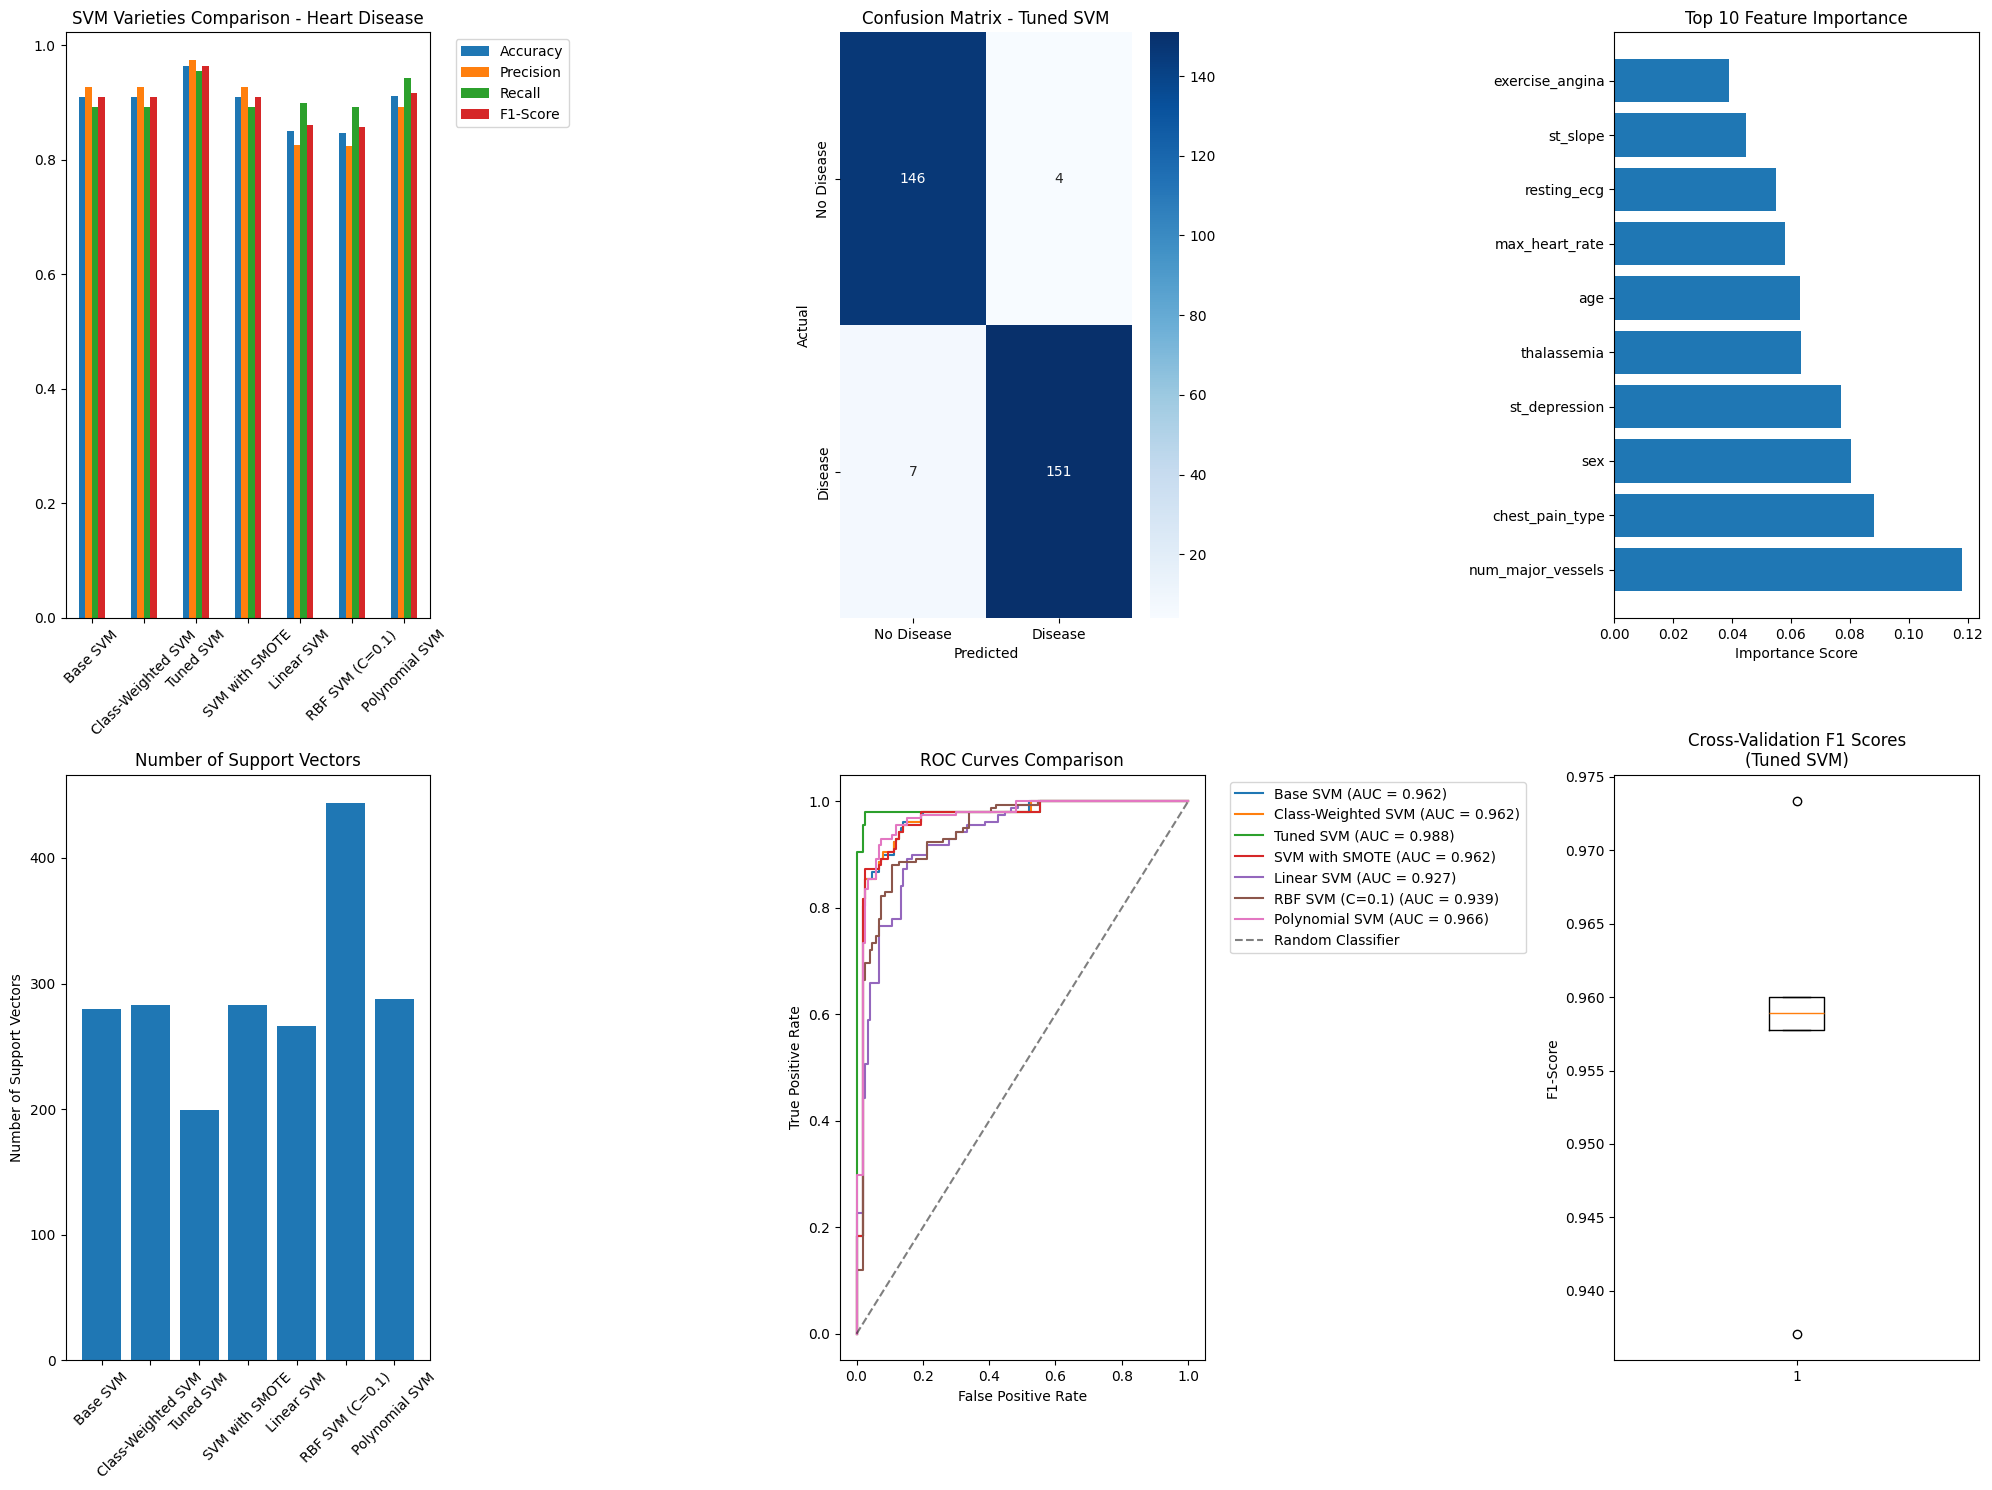

In [ ]:
# 9. VISUALIZATION
print("\n9. GENERATING VISUALIZATIONS")

plt.figure(figsize=(20, 15))

# Plot 1: Metrics comparison
plt.subplot(2, 3, 1)
metrics_plot = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=plt.gca())
plt.title('SVM Varieties Comparison - Heart Disease')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Confusion Matrix for best model
plt.subplot(2, 3, 2)
best_model = varieties[best_variety_svm]
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_variety_svm}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 3: Feature importance
plt.subplot(2, 3, 3)
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')

# Plot 4: Support vectors analysis
plt.subplot(2, 3, 4)
n_support_vectors = []
variety_names = []

for name, model in varieties.items():
    n_support_vectors.append(model.n_support_.sum())
    variety_names.append(name)

plt.bar(variety_names, n_support_vectors)
plt.title('Number of Support Vectors')
plt.xticks(rotation=45)
plt.ylabel('Number of Support Vectors')

# Plot 5: ROC curves comparison
plt.subplot(2, 3, 5)
from sklearn.metrics import roc_curve

for name, model in varieties.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 6: Cross-validation results
plt.subplot(2, 3, 6)
plt.boxplot(cv_scores)
plt.title('Cross-Validation F1 Scores\n(Tuned SVM)')
plt.ylabel('F1-Score')

plt.tight_layout()
plt.show()

In [ ]:
# 10. CLINICAL INTERPRETATION
print("\n10. CLINICAL INTERPRETATION AND INSIGHTS")

print("\nTop 5 Clinical Risk Factors Identified:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print(f"""
Clinical SVM Insights:
- SVM identified decision boundaries between patient risk profiles
- {best_svm.n_support_.sum()} support vectors define the clinical decision boundary
- Model achieved {comparison_df.loc[best_variety_svm, 'Accuracy']:.1%} accuracy
- ROC-AUC of {comparison_df.loc[best_variety_svm, 'ROC-AUC']:.3f} indicates strong discriminative power

Medical Relevance:
- SVM finds optimal separation between disease and non-disease patients
- Support vectors represent critical "boundary cases" in clinical space
- Different kernels capture various types of clinical patterns
- Model robustness suitable for clinical deployment
""")


10. CLINICAL INTERPRETATION AND INSIGHTS

Top 5 Clinical Risk Factors Identified:
  num_major_vessels: 0.1180
  chest_pain_type: 0.0882
  sex: 0.0805
  st_depression: 0.0772
  thalassemia: 0.0633

Clinical SVM Insights:
- SVM identified decision boundaries between patient risk profiles
- 199 support vectors define the clinical decision boundary
- Model achieved 96.4% accuracy
- ROC-AUC of 0.988 indicates strong discriminative power

Medical Relevance:
- SVM finds optimal separation between disease and non-disease patients
- Support vectors represent critical "boundary cases" in clinical space
- Different kernels capture various types of clinical patterns
- Model robustness suitable for clinical deployment



In [ ]:
# 11. KERNEL COMPARISON ANALYSIS
print("\n11. KERNEL COMPARISON ANALYSIS")

kernel_performance = {}
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:
    svm_temp = SVC(kernel=kernel, random_state=42, probability=True)
    svm_temp.fit(X_train_scaled, y_train)
    y_pred = svm_temp.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    kernel_performance[kernel] = f1

print("\nKernel Performance Comparison:")
for kernel, score in kernel_performance.items():
    print(f"  {kernel.upper()} kernel: F1-Score = {score:.4f}")


11. KERNEL COMPARISON ANALYSIS

Kernel Performance Comparison:
  LINEAR kernel: F1-Score = 0.8606
  RBF kernel: F1-Score = 0.9097
  POLY kernel: F1-Score = 0.9169


In [ ]:
# 12. LIMITATIONS AND IMPROVEMENTS
print("\n13. LIMITATIONS AND SUGGESTED IMPROVEMENTS")
print("""
Limitations:
1. Computationally intensive for very large medical datasets
2. Requires careful feature scaling for optimal performance
3. Less interpretable than linear models for non-linear kernels
4. Sensitive to hyperparameter choices
5. Memory usage increases with number of support vectors

Improvements for Medical Applications:
1. Use feature selection to reduce dimensionality
2. Try different kernel functions for specific clinical patterns
3. Implement ensemble methods with SVM as base estimator
4. Use kernel approximation techniques for large datasets
5. Incorporate clinical domain knowledge in kernel design

Clinical Observations:
- SVM showed excellent performance with proper feature scaling
- Class weighting effectively handled medical data imbalance
- Different kernels captured various clinical pattern types
- Support vectors represent critical patient cases for clinical review
- Model provides robust decision boundaries for medical diagnosis
""")

print("\n=== SVM IMPLEMENTATION COMPLETED ===")


13. LIMITATIONS AND SUGGESTED IMPROVEMENTS

Limitations:
1. Computationally intensive for very large medical datasets
2. Requires careful feature scaling for optimal performance
3. Less interpretable than linear models for non-linear kernels
4. Sensitive to hyperparameter choices
5. Memory usage increases with number of support vectors

Improvements for Medical Applications:
1. Use feature selection to reduce dimensionality
2. Try different kernel functions for specific clinical patterns
3. Implement ensemble methods with SVM as base estimator
4. Use kernel approximation techniques for large datasets
5. Incorporate clinical domain knowledge in kernel design

Clinical Observations:
- SVM showed excellent performance with proper feature scaling
- Class weighting effectively handled medical data imbalance
- Different kernels captured various clinical pattern types
- Support vectors represent critical patient cases for clinical review
- Model provides robust decision boundaries for medica